# Лабораторная работа 3

## Вариант 3
Построить прогноз на 8 месяцев методом сезонной декомпозиции.

Коэффициент загрузки гостиниц в процентах (Hotel Occupancy (in %))
Данные для Chicago Central Business District Hotel Statistics. 
Предоставлены средние значения процента занятых номеров за один день. 
Усреднение по отелям и по дням месяца.
Данные расположены в столбце x3 файла.

In [33]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [34]:
df = pd.read_csv('./data/data.csv', sep = ';')
df

,date1,date2,x1,x2,x3,x4
0,January,1994,44.3,104.04,51.9,72.15
1,February,1994,54.7,102.74,60.1,73.47
2,March,1994,61.9,105.23,65.0,74.91
3,April,1994,69.1,113.63,69.8,79.06
4,May,1994,70.8,120.77,72.4,82.07
...,...,...,...,...,...,...
115,August,2003,NaN,NaN,NaN,NaN
116,September,2003,NaN,NaN,NaN,NaN
117,October,2003,NaN,NaN,NaN,NaN
118,November,2003,NaN,NaN,NaN,NaN


In [35]:
# удалим пустые строки
df.dropna(inplace = True)
df

,date1,date2,x1,x2,x3,x4
0,January,1994,44.3,104.04,51.9,72.15
1,February,1994,54.7,102.74,60.1,73.47
2,March,1994,61.9,105.23,65.0,74.91
3,April,1994,69.1,113.63,69.8,79.06
4,May,1994,70.8,120.77,72.4,82.07
...,...,...,...,...,...,...
107,December,2002,54.8,148.95,46.6,99.10
108,January,2003,51.6,132.89,45.3,92.88
109,February,2003,52.7,127.44,50.8,90.99
110,March,2003,65.0,147.32,55.9,99.62


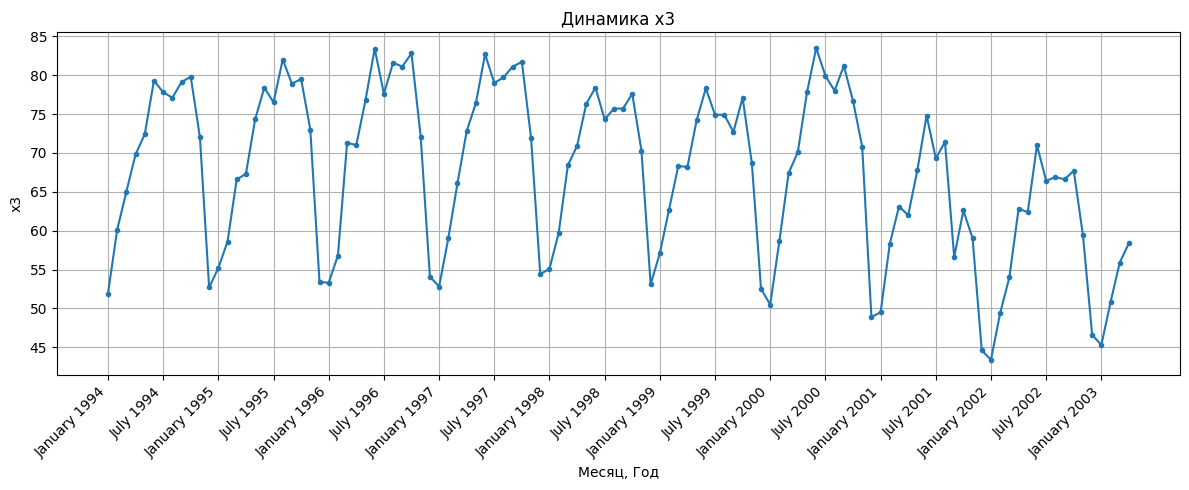

In [36]:
fig, ax = plt.subplots(figsize = (12, 5))

df['x3'].plot(ax = ax, grid = True, linewidth = 1.5, marker = 'o', markersize = 3)

labels = df['date1'].astype(str) + ' ' + df['date2'].astype(str)

step = 6
ax.set_xticks(range(0, len(df), step))
ax.set_xticklabels(labels[::step], rotation=45, ha='right')

plt.title('Динамика x3')
plt.xlabel('Месяц, Год')
plt.ylabel('x3')
plt.tight_layout()
plt.show()

In [37]:
df['date'] = pd.to_datetime(df['date2'].astype(str) + '-' + df['date1'], format = '%Y-%B')
df = df.set_index('date').sort_index()
df = df.dropna(subset = ['x3'])

In [38]:
# декомпозиция (период = 12 месяцев)
result = seasonal_decompose(df['x3'], model = 'additive', period = 12)

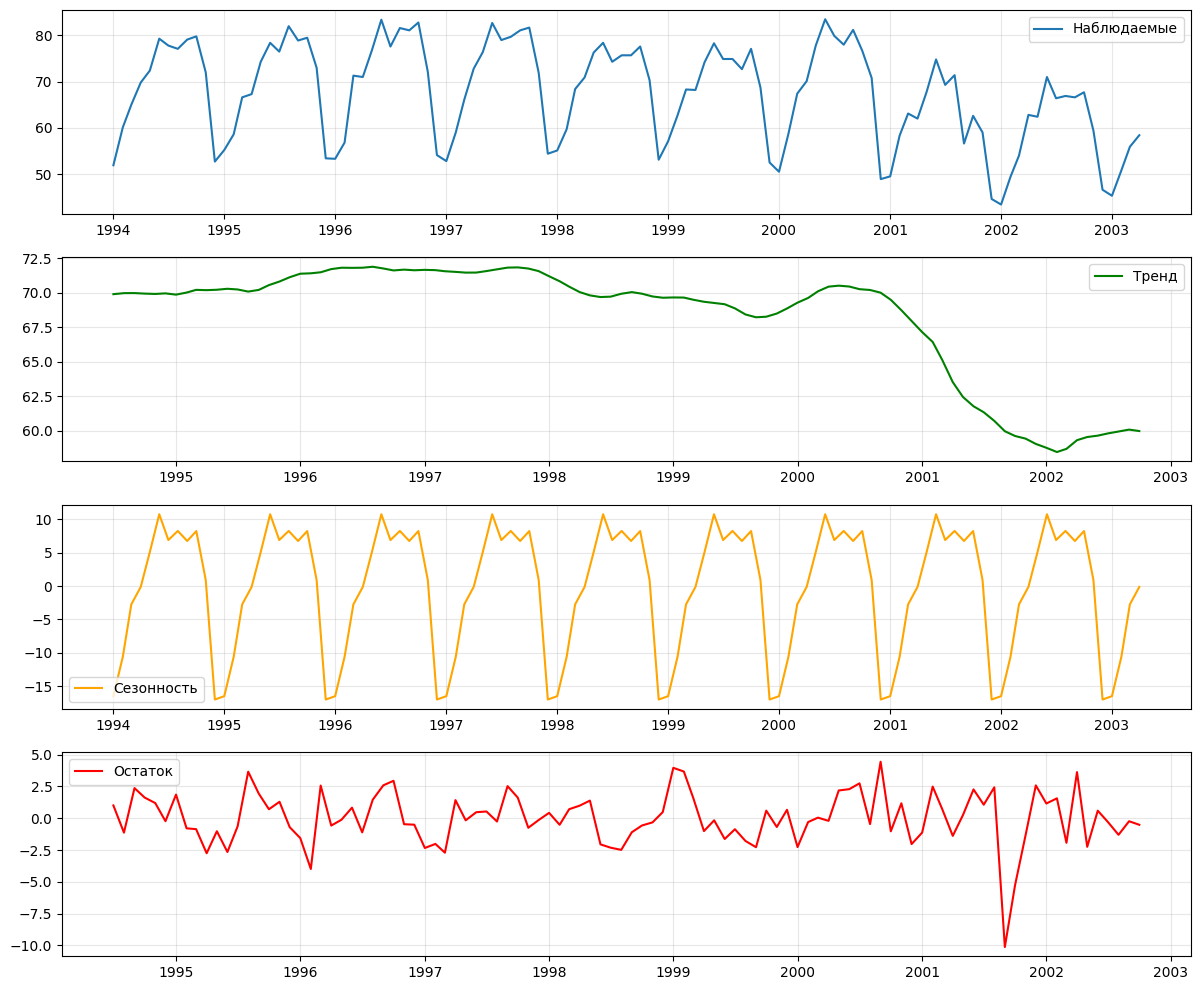

In [39]:
fig, axes = plt.subplots(4, 1, figsize = (12, 10))
axes[0].plot(result.observed, label = 'Наблюдаемые')
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

axes[1].plot(result.trend, label = 'Тренд', color = 'green')
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

axes[2].plot(result.seasonal, label = 'Сезонность', color = 'orange')
axes[2].legend()
axes[2].grid(True, alpha = 0.3)

axes[3].plot(result.resid, label = 'Остаток', color = 'red')
axes[3].legend()
axes[3].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

In [40]:
# прогноз на 8 месяцев
h = 8

# гарантируем месячную частоту (начало месяца)
y = df['x3'].asfreq('MS')

# тренд: линейная экстраполяция trend-компоненты
trend = result.trend
x = np.arange(len(y))
mask = ~np.isnan(trend.values)
coef = np.polyfit(x[mask], trend.values[mask], 1)
x_future = np.arange(len(y), len(y) + h)
trend_future = np.polyval(coef, x_future)

# сезонность: усредняем сезонную компоненту по месяцам года
seasonal_by_month = result.seasonal.groupby(result.seasonal.index.month).mean()

future_index = pd.date_range(
    start = y.index.max() + pd.offsets.MonthBegin(1),
    periods = h,
    freq = 'MS',
)
seasonal_future = future_index.month.map(seasonal_by_month).to_numpy()

# прогноз = тренд + сезонность
y_forecast = trend_future + seasonal_future

forecast_df = pd.DataFrame({
    'x3_forecast': y_forecast,
}, index = future_index)
forecast_df.index.name = 'date'
forecast_df

,x3_forecast
date,
2003-05-01,67.182646
2003-06-01,72.732464
2003-07-01,68.754851
2003-08-01,70.007273
2003-09-01,68.393491
2003-10-01,69.767209
2003-11-01,62.311761
2003-12-01,44.284495


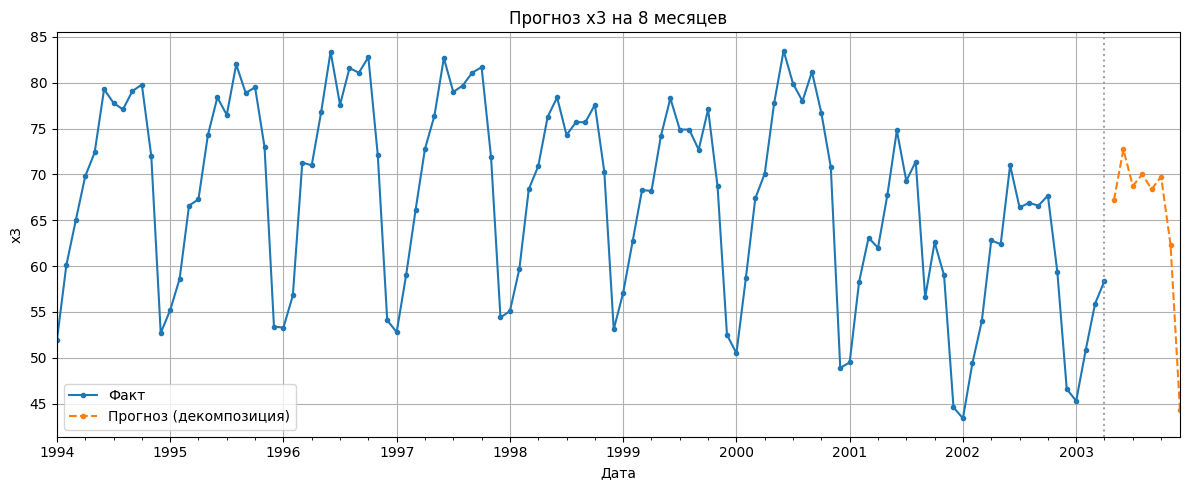

In [41]:
# визуализация прогноза
fig, ax = plt.subplots(figsize = (12, 5))

y.plot(ax = ax, label = 'Факт', grid = True, linewidth = 1.5, marker = 'o', markersize = 3)
forecast_df['x3_forecast'].plot(
    ax = ax,
    label = 'Прогноз (декомпозиция)',
    linewidth = 1.5,
    linestyle = '--',
    marker = 'o',
    markersize = 3,
    grid = True,
)

ax.axvline(y.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Прогноз x3 на 8 месяцев')
ax.set_xlabel('Дата')
ax.set_ylabel('x3')
ax.legend()
plt.tight_layout()
plt.show()